In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1- Load Dataset

In [4]:
# load dataset
df = pd.read_csv("housing.csv")

# first look
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 2. Data Quality Assessment

### 2.1 Basic dataset overview

In [5]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


### 2.2 Check missing values

In [6]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Only total_bedrooms contains missing values (207 rows).
All other columns have no missing values.

### 2.3 check duplicate rows

In [8]:
df.duplicated().sum()

np.int64(0)

The dataset contains 0 duplicate rows.
No duplicate removal is required.

### 2.4 Data types

In [9]:
df.dtypes

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

All columns have appropriate data types.
Numerical features are stored as float64,
and ocean_proximity is correctly stored as an object (categorical variable).
No data type conversion is needed at this stage.

### 2.5 Detect outliers

In [18]:
Q1 = df["median_income"].quantile(0.25)
Q3 = df["median_income"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["median_income"] < lower_bound) | (df["median_income"] > upper_bound)]

print("Number of outliers:", outliers.shape[0])
outliers.head()

Number of outliers: 681


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
131,-122.19,37.84,18.0,1617.0,210.0,533.0,194.0,11.6017,392600.0,NEAR BAY
134,-122.19,37.83,28.0,1326.0,184.0,463.0,190.0,8.2049,335200.0,NEAR BAY
135,-122.20,37.83,26.0,1589.0,223.0,542.0,211.0,8.4010,351200.0,NEAR BAY


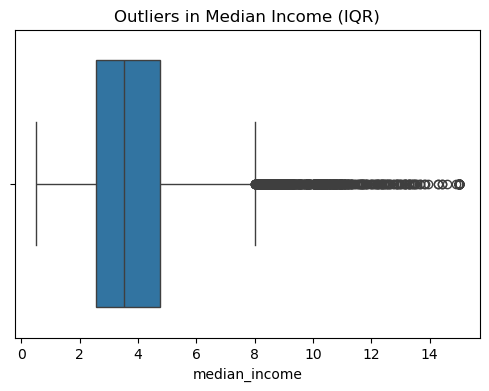

In [20]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["median_income"])
plt.title("Outliers in Median Income (IQR)")
plt.show()

## 3. Handling Missing Values 

total_bedrooms contains missing values:

In [14]:
df[df['total_bedrooms'].isnull()].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
290,-122.16,37.77,47.0,1256.0,NaN,570.0,218.0,4.3750,161900.0,NEAR BAY
341,-122.17,37.75,38.0,992.0,NaN,732.0,259.0,1.6196,85100.0,NEAR BAY
538,-122.28,37.78,29.0,5154.0,NaN,3741.0,1273.0,2.5762,173400.0,NEAR BAY
563,-122.24,37.75,45.0,891.0,NaN,384.0,146.0,4.9489,247100.0,NEAR BAY
696,-122.10,37.69,41.0,746.0,NaN,387.0,161.0,3.9063,178400.0,NEAR BAY


### The used Srategy: Median Imputation 

This strategy is selected because, the column is numerical and may contain outliers.

In [15]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

Now verify:

In [16]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

## 4. Handling Outliers

### The used Srategy: Capping outliers 

In [21]:
df["median_income_capped"] = df["median_income"].clip(lower=lower_bound, upper=upper_bound)

In [22]:
Q1_new = df["median_income_capped"].quantile(0.25)
Q3_new = df["median_income_capped"].quantile(0.75)
IQR_new = Q3_new - Q1_new

lower_new = Q1_new - 1.5 * IQR_new
upper_new = Q3_new + 1.5 * IQR_new

outliers_after = df[
    (df["median_income_capped"] < lower_new) |
    (df["median_income_capped"] > upper_new)
]

print("Number of outliers after capping:", outliers_after.shape[0])

Number of outliers after capping: 0


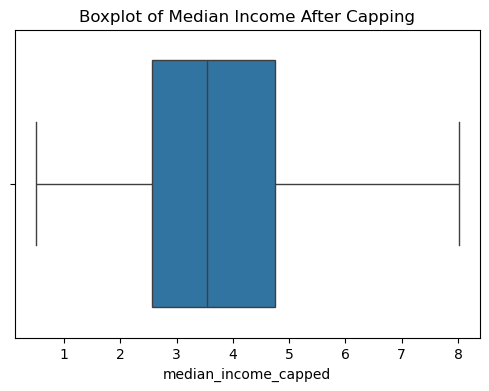

In [23]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["median_income_capped"])
plt.title("Boxplot of Median Income After Capping")
plt.show()

## 5. Normalize the numerical features

### 5.1 Min-Max

In [26]:
from sklearn.preprocessing import MinMaxScaler

# select numeric columns
numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns

# apply Min-Max normalization
scaler = MinMaxScaler()
df_minmax = df.copy()
df_minmax[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# preview
df_minmax.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,median_income_capped
0,0.211155,0.567481,0.784314,0.022331,0.019863,0.008941,0.020556,0.539668,0.902266,NEAR BAY,1.000000
1,0.212151,0.565356,0.392157,0.180503,0.171477,0.067210,0.186976,0.538027,0.708247,NEAR BAY,1.000000
2,0.210159,0.564293,1.000000,0.037260,0.029330,0.013818,0.028943,0.466028,0.695051,NEAR BAY,0.899426
3,0.209163,0.564293,1.000000,0.032352,0.036313,0.015555,0.035849,0.354699,0.672783,NEAR BAY,0.684562
4,0.209163,0.564293,1.000000,0.041330,0.043296,0.015752,0.042427,0.230776,0.674638,NEAR BAY,0.445394


### 5.2 Z-score

In [27]:
from sklearn.preprocessing import StandardScaler

# select numeric columns
numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns

# apply Z-score normalization
scaler = StandardScaler()
df_zscore = df.copy()
df_zscore[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# preview
df_zscore.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,median_income_capped
0,-1.327835,1.052548,0.982143,-0.804819,-0.972476,-0.974429,-0.977033,2.344766,2.129631,NEAR BAY,2.541006
1,-1.322844,1.043185,-0.607019,2.045890,1.357143,0.861439,1.669961,2.332238,1.314156,NEAR BAY,2.541006
2,-1.332827,1.038503,1.856182,-0.535746,-0.827024,-0.820777,-0.843637,1.782699,1.258693,NEAR BAY,2.085156
3,-1.337818,1.038503,1.856182,-0.624215,-0.719723,-0.766028,-0.733781,0.932968,1.165100,NEAR BAY,1.111288
4,-1.337818,1.038503,1.856182,-0.462404,-0.612423,-0.759847,-0.629157,-0.012881,1.172900,NEAR BAY,0.027262


## 6. Applying PCA

### Checking the correlation before applying PCA

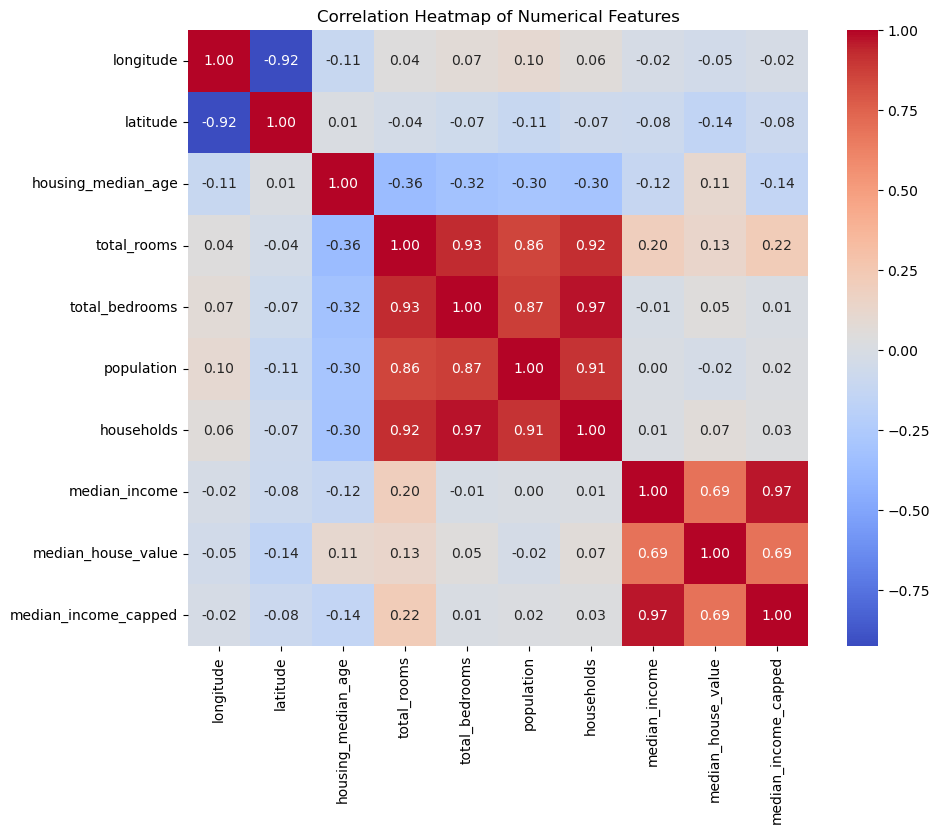

In [28]:
plt.figure(figsize=(10, 8))
corr_matrix = df.select_dtypes(include=["float64", "int64"]).corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

### Apply the PCA

In [30]:
from sklearn.decomposition import PCA

# select numeric columns from z-score normalized data
numeric_cols = df_zscore.select_dtypes(include=["float64", "int64"]).columns

# apply PCA
pca = PCA()
pca_components = pca.fit_transform(df_zscore[numeric_cols])

# explained variance ratio
explained_variance = pca.explained_variance_ratio_
explained_variance

array([0.39346161, 0.25740694, 0.19010698, 0.09338054, 0.03516976,
       0.01443187, 0.00630799, 0.00461861, 0.00319102, 0.00192468])

In [34]:
from sklearn.decomposition import PCA

# numeric columns from z-score normalized data
numeric_cols = df_zscore.select_dtypes(include=["float64", "int64"]).columns

# project data onto 2 principal components
pca_2d = PCA(n_components=2)
pca_projection = pca_2d.fit_transform(df_zscore[numeric_cols])

# create dataframe for projection
df_pca_2d = pd.DataFrame(pca_projection, columns=["PC1", "PC2"])

df_pca_2d.head()

,PC1,PC2
0,-1.485420,4.191886
1,3.420407,2.935240
2,-1.517236,3.103294
3,-1.631178,1.957342
4,-1.661783,0.748520


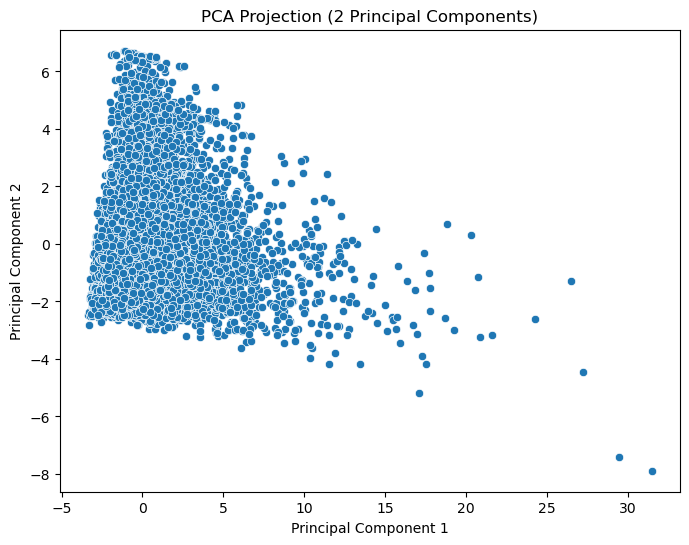

In [35]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="PC1", y="PC2", data=df_pca_2d)
plt.title("PCA Projection (2 Principal Components)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()